# TP Deep Learning — CNN, RNN et GRU (**datasets réels**) — Exercices guidés + visualisations

Ce TP est orienté **compréhension** : on veut **voir** ce qui se passe.
Il contient :
- visualisations du dataset (images/texte)
- visualisations des tenseurs (shapes)
- courbes loss/accuracy
- (optionnel) matrice de confusion

Datasets :
- **CNN : MNIST** (classification d’images 28×28)
- **RNN/GRU : AG_NEWS** (classification de texte : 4 catégories)

> Le TP tourne vite en utilisant des **sous‑ensembles**.


In [1]:
# Si besoin (Colab / env minimal) :
# !pip install torchvision torchtext torchdata -q

import os, re, math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

print('Torch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Torch: 2.10.0+cpu
Device: cpu


## Partie 1 — CNN sur MNIST (images)

### 1.1 Charger le dataset MNIST


In [2]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print('Train size:', len(train_ds), 'Test size:', len(test_ds))

# Sous-ensemble (TP)
train_subset = Subset(train_ds, range(0, 8000))
test_subset  = Subset(test_ds,  range(0, 2000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_subset,  batch_size=256, shuffle=False, num_workers=0)


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.80MB/s]


Train size: 60000 Test size: 10000


### 1.2 Visualiser MNIST : quelques images + labels

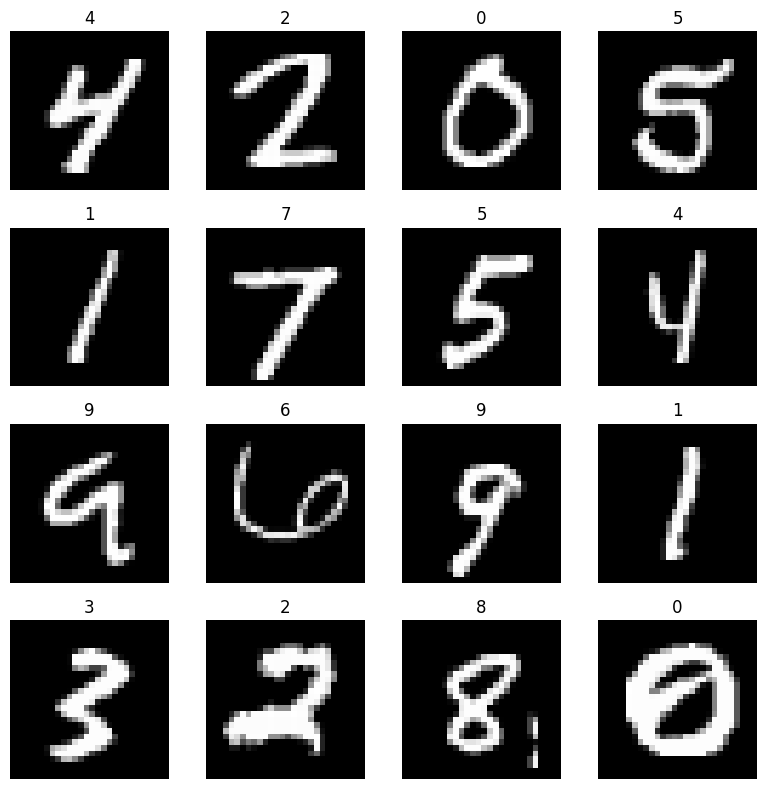

In [3]:
import numpy as np

def show_mnist_grid(dataset, n=16):
    # Affiche n images dans une grille
    idxs = torch.randperm(len(dataset))[:n].tolist()
    cols = int(math.sqrt(n))
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols*2, rows*2))
    for i, idx in enumerate(idxs):
        x, y = dataset[idx]
        # x: (1,28,28) -> (28,28)
        img = x[0].numpy()
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(str(y))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_mnist_grid(train_ds, n=16)


### 1.3 Distribution des classes (sur le sous-ensemble)

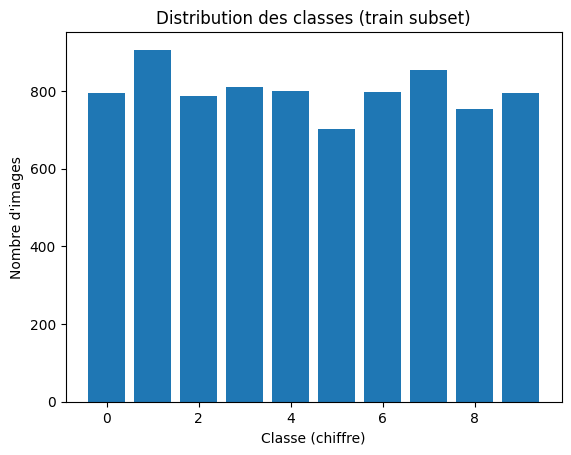

Counts: [795 906 788 811 799 702 798 853 753 795]


In [4]:
# Comptage des labels sur le sous-ensemble d'entraînement
labels = []
for i in range(len(train_subset)):
    _, y = train_subset[i]
    labels.append(int(y))

counts = np.bincount(np.array(labels), minlength=10)

plt.figure()
plt.bar(range(10), counts)
plt.xlabel('Classe (chiffre)')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes (train subset)')
plt.show()

print('Counts:', counts)


### Exercice 1 — Construire le CNN

#### Indices
- Conv : `nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)`
- Pool : `nn.MaxPool2d(2)`
- Après deux poolings : `28→14→7`
- Donc avant Linear : `16 * 7 * 7`

#### Objectif
Obtenir des logits de shape `(batch, 10)`.


In [8]:
from torch.nn.modules import Conv2d
#  À COMPLÉTER
cnn = nn.Sequential(
    # TODO: Conv2d(1, 8, 3, padding=1)
    nn.Conv2d(1, 8, 3, padding=1), # Added a comma here
    nn.ReLU(),
    nn.MaxPool2d(2),
    # TODO: Conv2d(8, 16, 3, padding=1)
    nn.Conv2d(8, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    # TODO: Linear(16*7*7, 10)
    nn.Linear(16*7*7, 10)
).to(device)

# Test shapes
xb, yb = next(iter(train_loader))
xb = xb.to(device)
logits = cnn(xb)
print('xb:', xb.shape, 'logits:', logits.shape)

xb: torch.Size([64, 1, 28, 28]) logits: torch.Size([64, 10])


### Exercice 2 — Entraînement CNN + courbes

On veut **voir** la loss et l’accuracy évoluer.

#### Indices
- Loss : `nn.CrossEntropyLoss()`
- Optim : Adam ou SGD
- Stocker `loss`, `train_acc`, `test_acc` dans des listes puis tracer avec matplotlib.


Epoch 1: loss=0.0751 train_acc=0.978 test_acc=0.963
Epoch 2: loss=0.0587 train_acc=0.983 test_acc=0.970
Epoch 3: loss=0.0527 train_acc=0.985 test_acc=0.967


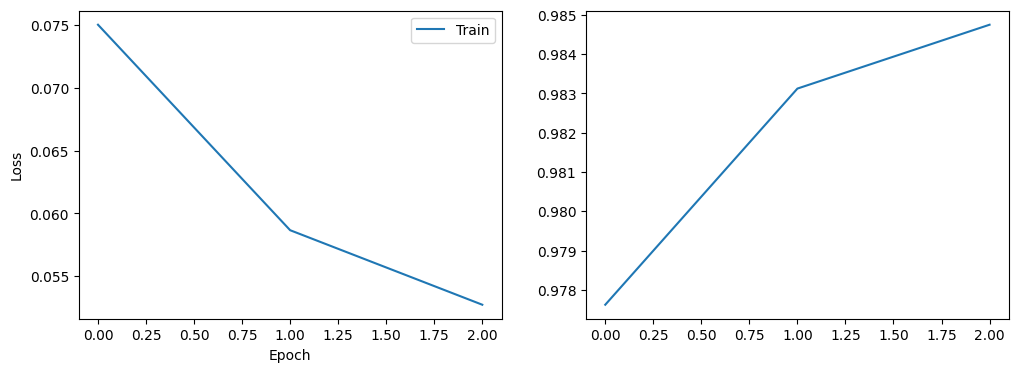

In [11]:
#  À COMPLÉTER
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # TODO: zero_grad
        optimizer.zero_grad()
        # TODO: forward
        logits = model(xb)

        # TODO: loss
        loss = loss_fn(logits, yb)

        # TODO: backward + step
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
    return total_loss/total, total_correct/total

@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    total_correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total += xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
    return total_correct/total

loss_hist = []
train_acc_hist = []
test_acc_hist = []

for epoch in range(3):
    tr_loss, tr_acc = train_one_epoch(cnn, train_loader)
    te_acc = eval_acc(cnn, test_loader)
    loss_hist.append(tr_loss)
    train_acc_hist.append(tr_acc)
    test_acc_hist.append(te_acc)
    print(f'Epoch {epoch+1}: loss={tr_loss:.4f} train_acc={tr_acc:.3f} test_acc={te_acc:.3f}')

# TODO: tracer les courbes (loss et accuracy)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(loss_hist, label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(
    train_acc_hist, label='Train'
)




### (Optionnel) Matrice de confusion sur MNIST

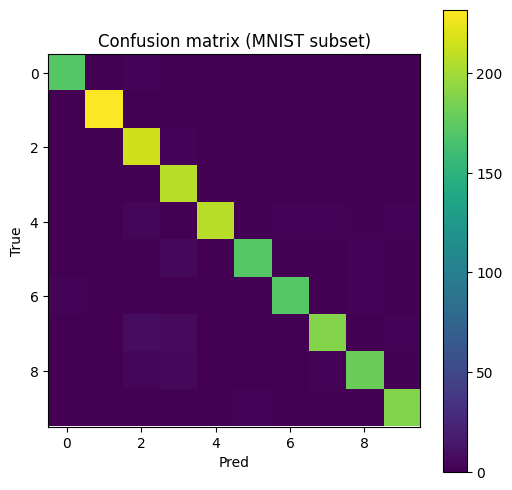

In [12]:
# Optionnel : nécessite scikit-learn
# !pip install scikit-learn

try:
    from sklearn.metrics import confusion_matrix
    import numpy as np

    @torch.no_grad()
    def confusion_on_loader(model, loader, num_classes=10):
        model.eval()
        ys, ps = [], []
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
        y_true = np.concatenate(ys)
        y_pred = np.concatenate(ps)
        return confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    cm = confusion_on_loader(cnn, test_loader)
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title('Confusion matrix (MNIST subset)')
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.colorbar()
    plt.show()
except Exception as e:
    print('Optionnel: scikit-learn non installé ou autre erreur:', e)


## Partie 2 — RNN/GRU sur AG_NEWS (texte)

### 2.1 Charger AG_NEWS et regarder le contenu


In [23]:
# Install torchtext if not already installed
!pip install torchtext

from torchtext.datasets import AG_NEWS

train_iter = AG_NEWS(split='train')
test_iter  = AG_NEWS(split='test')

train_list = list(train_iter)
test_list  = list(test_iter)

print('Train size:', len(train_list), 'Test size:', len(test_list))

# Sous-ensemble TP
train_list = train_list[:8000]
test_list  = test_list[:2000]

print('Using subset -> Train:', len(train_list), 'Test:', len(test_list))

label_names = {1:'World', 2:'Sports', 3:'Business', 4:'Sci/Tech'}
for i in range(3):
    label, text = train_list[i]
    print('\n--- Exemple', i, '---') # Fixed: Escaped newline character
    print('Label:', label, label_names.get(label,'?'))
    print('Text:', text[:300], '...')


OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

### 2.2 Tokenisation + longueur des séquences (visualisation)

In [ ]:
import numpy as np
from collections import Counter

def tokenize(text: str):
    text = text.lower()
    return re.findall(r"[a-z0-9']+", text)

lengths = [len(tokenize(t)) for _, t in train_list]
plt.figure()
plt.hist(lengths, bins=50)
plt.xlabel('Nb tokens')
plt.ylabel('Nb exemples')
plt.title('Distribution longueur des textes (train subset)')
plt.show()

print('Longueur moyenne:', float(np.mean(lengths)))
print('90e percentile:', float(np.percentile(lengths, 90)))


### 2.3 Construire le vocabulaire (visualiser les mots fréquents)

In [ ]:
MAX_VOCAB = 20000
MAX_LEN = 80

counter = Counter()
for label, text in train_list:
    counter.update(tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)
itos = ['<pad>', '<unk>'] + [w for w, _ in most_common]
stoi = {w:i for i,w in enumerate(itos)}

top_words = counter.most_common(15)
words = [w for w,_ in top_words]
freqs = [c for _,c in top_words]

plt.figure(figsize=(8,4))
plt.bar(words, freqs)
plt.xticks(rotation=45, ha='right')
plt.title('Top mots fréquents (train subset)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

print('Vocab size:', len(itos))


### 2.4 Encoder les textes + vérifier un exemple encodé

In [ ]:
def encode(text: str):
    toks = tokenize(text)
    ids = [stoi.get(t, 1) for t in toks]
    if len(ids) < MAX_LEN:
        ids = ids + [0]*(MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return torch.tensor(ids, dtype=torch.long)

def make_tensor_dataset(data_list):
    xs, ys = [], []
    for label, text in data_list:
        xs.append(encode(text))
        ys.append(label - 1)  # 0..3
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)

X_train, y_train = make_tensor_dataset(train_list)
X_test, y_test   = make_tensor_dataset(test_list)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)

# Voir un exemple : tokens -> ids
label, text = train_list[0]
toks = tokenize(text)[:20]
ids = [stoi.get(t, 1) for t in toks]
print('Label:', label, label_names[label])
print('Tokens:', toks)
print('Ids   :', ids)


In [ ]:
train_loader_txt = DataLoader(list(zip(X_train, y_train)), batch_size=64, shuffle=True)
test_loader_txt  = DataLoader(list(zip(X_test, y_test)), batch_size=256, shuffle=False)


### Exercice 3 — Modèle RNN (texte)

On veut un pipeline :
Embedding → RNN → dernière sortie → Linear → logits (4 classes)

#### Indices
- `nn.Embedding(vocab, emb_dim, padding_idx=0)`
- `nn.RNN(emb_dim, H, batch_first=True)`
- `out[:, -1, :]` = dernier pas de temps (après padding/troncature)


In [21]:
# À COMPLÉTER
VOCAB_SIZE = len(itos)
EMB = 64
H = 64
NUM_CLASSES = 4

class TextRNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO
        self.emb = nn.Embedding(VOCAB_SIZE, EMB, padding_idx=0)
        self.rnn = nn.RNN(emb_dim, H, batch_first=True)
        self.fc = nn.Linear(H, NUM_CLASSES)

    def forward(self, x):
        # x: (B, T)
        z = self.emb(x)
        # z: (B, T, EMB)
        out, h = self.rnn(z)
        out, h = out[:, -1, :], h[-1]
        logits = self.fc(out)
        last = self.fc(h)
        logits = self.fc(last)
        return logits

rnn_model = TextRNN().to(device)
xb, yb = next(iter(train_loader_txt))
logits = rnn_model(xb.to(device))
print('logits shape:', logits.shape)  # (B,4)


NameError: name 'itos' is not defined

### Exercice 4 — Modèle GRU (texte)

Même chose mais avec GRU (plus robuste).


In [25]:
# À COMPLÉTER
class TextGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = None
        self.gru = None
        self.fc = None

    def forward(self, x):
        z = self.emb(x)
        out, h = out[:, -1, :], h[-1]
        last = self.fc(h)
        logits = self.fc(last)
        return logits

gru_model = TextGRU().to(device)
xb, yb = next(iter(train_loader_txt))
logits = gru_model(xb.to(device))
print('logits shape:', logits.shape)  # (B,4)


NameError: name 'train_loader_txt' is not defined

### Exercice 5 — Entraîner le modèle texte + visualiser

On veut tracer la loss et les accuracies.


In [24]:
# À COMPLÉTER
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)

def train_one_epoch_text(model, loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # TODO
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # TODO

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
    return total_loss/total, total_correct/total

@torch.no_grad()
def eval_text(model, loader):
    model.eval()
    total_correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total += xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
    return total_correct/total

loss_hist = []
train_acc_hist = []
test_acc_hist = []

for epoch in range(2):
    tr_loss, tr_acc = train_one_epoch_text(gru_model, train_loader_txt)
    te_acc = eval_text(gru_model, test_loader_txt)
    loss_hist.append(tr_loss)
    train_acc_hist.append(tr_acc)
    test_acc_hist.append(te_acc)
    print(f'Epoch {epoch+1}: loss={tr_loss:.4f} train_acc={tr_acc:.3f} test_acc={te_acc:.3f}')

# TODO: tracer loss + accuracy


NameError: name 'gru_model' is not defined

## Questions de compréhension (à rendre)
1) Pourquoi un CNN est plus adapté aux images qu’un MLP naïf ?  
2) Pourquoi les RNN ont du mal avec les dépendances longues ?  
3) Quelle est l’idée du GRU (portes/gates) ?  
4) Pourquoi utilise-t-on un `Embedding` pour le texte ?  
5) Quelle différence entre `out[:, -1, :]` et `h[-1]` ?  


Réponses

1) CNN vs MLP pour les images
Un CNN (Convolutional Neural Network) est bien plus performant qu’un MLP naïf car il exploite la structure spatiale des images grâce au partage de poids. Là où un MLP traite chaque pixel comme une entité indépendante et convertit l'image en un vecteur, le CNN utilise des filtres locaux qui glissent sur l'image pour détecter des motifs (bords, textures, formes). Cela permet non seulement de réduire drastiquement le nombre de paramètres à entraîner, mais aussi d'obtenir une invariance spatiale : le modèle reconnaît un objet quel que soit son emplacement dans le cadre.

2) Les RNN et les dépendances longues
Le principal obstacle des RNN classiques est le vanishing gradient. Lors de l'entraînement sur de longues séquences, l'erreur est rétropropagée à travers chaque pas de temps par des multiplications successives des poids. Si ces derniers sont inférieurs à 1, le signal s'affaiblit exponentiellement jusqu'à devenir quasi nul pour les premiers éléments de la séquence. En conséquence, le réseau finit par "oublier" les informations du début de la phrase, perdant ainsi le contexte nécessaire pour comprendre les dépendances lointaines.

3) Le concept des portes dans le GRU
L'idée centrale du GRU est d'introduire des mécanismes de contrôle, appelés portes (gates), pour réguler activement le flux d'information. La Update Gate décide quelle proportion de l'ancienne mémoire doit être conservée et quelle part de la nouvelle information doit être intégrée, tandis que la Reset Gate détermine quelle partie de l'état précédent est devenue inutile et doit être ignorée. Ce système permet au réseau de maintenir une mémoire sélective et de lutter efficacement contre l'oubli à long terme sans la complexité excessive d'un LSTM.

4) L'utilité de l'Embedding pour le texte
On utilise une couche d'Embedding car le texte brut n'est pas compréhensible par un modèle mathématique et le codage binaire classique (One-Hot Encoding) est inefficace. L'Embedding transforme chaque mot en un vecteur dense de nombres réels de taille fixe. Ce passage dans un espace vectoriel continu permet de capturer des relations sémantiques : des mots ayant un sens ou un contexte similaire (comme "avion" et "pilote") se retrouvent géométriquement proches dans cet espace, ce qui aide grandement le modèle à généraliser ses prédictions.

5) Différence entre out[:, -1, :] et h[-1]
Bien que ces deux termes pointent souvent vers la "fin" de la séquence, leur structure diffère selon l'architecture. La notation out[:, -1, :] extrait l'état caché produit au tout dernier pas de temps de la couche supérieure ; c'est la sortie temporelle finale utilisée pour la prédiction. À l'inverse, h[-1] (souvent issu du tuple d'états cachés) représente l'état final spécifique à la dernière couche du réseau. Si le modèle possède plusieurs couches empilées (stacked), h contient les états finaux de chaque couche, tandis que out contient les sorties de chaque pas de temps pour la dernière couche seulement.